1. 축별 회전 행렬을 만드는 rot_x, rot_y, rot_z 를 직접 작성하세요(각도는 라디안으로 받습니다). rot_z 로 90도 회전시켰을 때 점 (1,0,0)이 (0,1,0)으로 가는지 확인하세요.  
오른손 좌표계를 기준으로 각 축(X, Y, Z) 중심의 회전 행렬을 정의 및 rot_z를 사용하여 90도 회전했을 때 점 (1, 0, 0)이 (0, 1, 0)으로 되는지 검증

In [28]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(),"..")))

import numpy as np
import matplotlib.pyplot as plt
from src.rotation import rot_x, rot_y, rot_z, rodrigues

p = np.array([1.0, 0.0, 0.0])
theta_90 = np.pi / 2

# Z축 기준 90도 회전 적용
R_z_90 = rot_z(theta_90)
p_transformed = R_z_90 @ p
print(f"rot_z(90도) 변환 후 결과 점: {p_transformed}")

rot_z(90도) 변환 후 결과 점: [6.123234e-17 1.000000e+00 0.000000e+00]


In [29]:
expected_p = np.array([0.0, 1.0, 0.0])
is_correct = np.allclose(p_transformed, expected_p, atol=1e-15)
print(f"[검증] (1,0,0) -> (0,1,0) 변환 일치 여부: {is_correct}")
assert is_correct, "변환 결과가 일치하지 않습니다."

[검증] (1,0,0) -> (0,1,0) 변환 일치 여부: True


2. 세 축 회전을 각각 Matplotlib 3D로 그려, 회전축 성분은 보존된다는 사실을 눈으로 확인할 수 있게 시각화하세요.  
지정된 난수 시드를 사용하여 3차원 샘플 데이터를 생성, 각 축별로 45도 회전 후 각 회전축에 해당하는 좌표 성분이 변하지 않고 완벽히 보존됨을 Matplotlib 3D 플롯과 수치 연산으로 증명

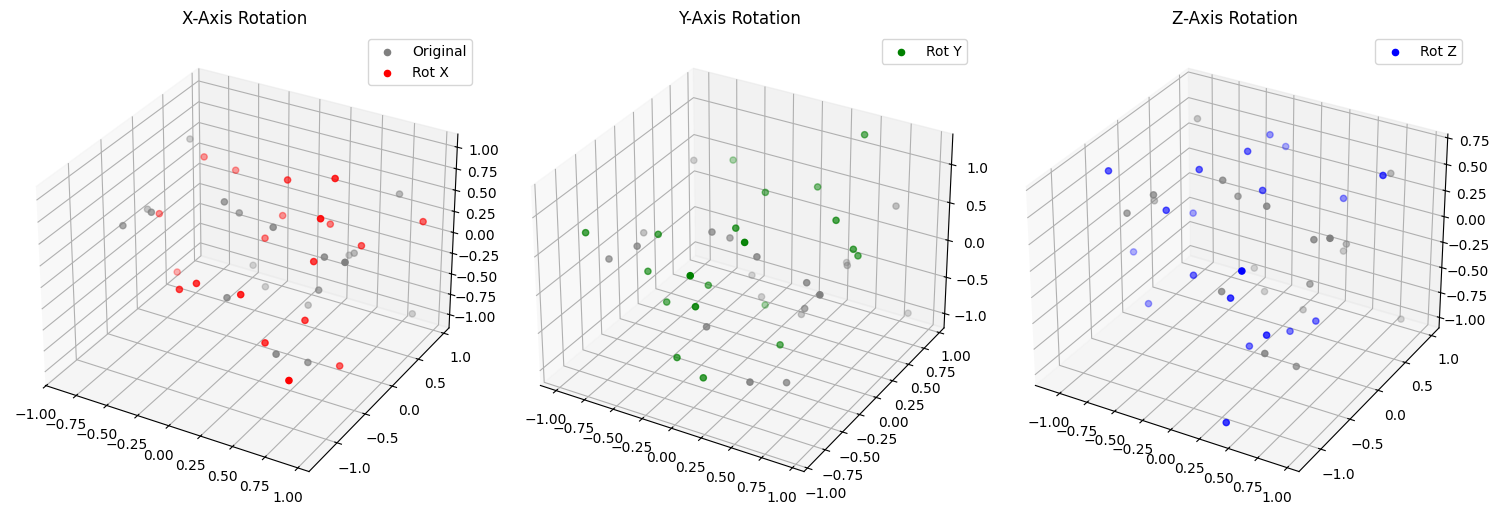

In [30]:
rng = np.random.default_rng(42)
sample_points = rng.uniform(-1.0, 1.0, (3, 20))

test_angle = rng.uniform(0, 2*np.pi)

Rx = rot_x(test_angle)
Ry = rot_y(test_angle)
Rz = rot_z(test_angle)

transformed_x = Rx @ sample_points
transformed_y = Ry @ sample_points
transformed_z = Rz @ sample_points

fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(sample_points[0], sample_points[1], sample_points[2], color='gray', label='Original')
ax1.scatter(transformed_x[0], transformed_x[1], transformed_x[2], color='red', label='Rot X')
ax1.set_title("X-Axis Rotation")
ax1.legend()

ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(sample_points[0], sample_points[1], sample_points[2], color='gray')
ax2.scatter(transformed_y[0], transformed_y[1], transformed_y[2], color='green', label='Rot Y')
ax2.set_title("Y-Axis Rotation")
ax2.legend()

ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(sample_points[0], sample_points[1], sample_points[2], color='gray')
ax3.scatter(transformed_z[0], transformed_z[1], transformed_z[2], color='blue', label='Rot Z')
ax3.set_title("Z-Axis Rotation")
ax3.legend()

plt.tight_layout()
plt.show()

In [31]:
check_x = np.allclose(sample_points[0], transformed_x[0])
check_y = np.allclose(sample_points[1], transformed_y[1])
check_z = np.allclose(sample_points[2], transformed_z[2])

print("[검증] X축 회전 시 X좌표 보존:", check_x)
print("[검증] Y축 회전 시 Y좌표 보존:", check_y)
print("[검증] Z축 회전 시 Z좌표 보존:", check_z)

assert check_x and check_y and check_z

[검증] X축 회전 시 X좌표 보존: True
[검증] Y축 회전 시 Y좌표 보존: True
[검증] Z축 회전 시 Z좌표 보존: True


3. 합성 순서가 다르면 결과가 달라짐을 보이세요. y축 회전과 z축 회전을 두 순서로 합성해 결과 행렬이 다름을 확인하고, 같은 초기 자세가 두 순서로 어떻게 다르게 끝나는지 나란히 3D로 그려 비교하세요.  
임의의 각도 2개와 테스트용 3차원 점 데이터를 추출하고 Y축 회전 후 Z축 회전을 한 결과와 그 반대 순서 결과의 최종 자세가 다름을 비교

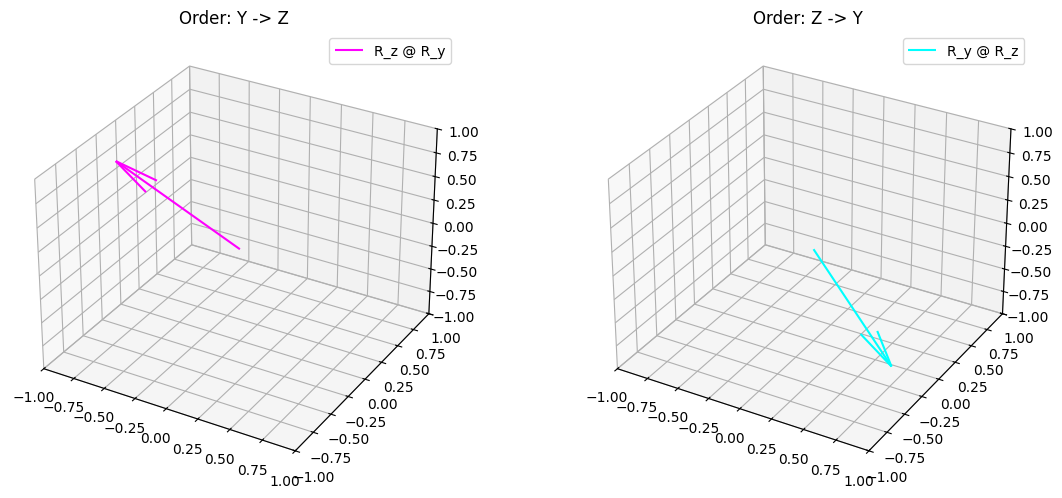

In [32]:
rng = np.random.default_rng(42)

angles = rng.uniform(0, 2*np.pi, 2)
ang_y, ang_z = angles[0], angles[1]

test_vector = rng.uniform(-1.0, 1.0, (3, 1))

R_y = rot_y(ang_y)
R_z = rot_z(ang_z)

# 두 가지 행렬 합성 순서 계산
R_zy = R_z @ R_y
R_yz = R_y @ R_z

v_zy = R_zy @ test_vector
v_yz = R_yz @ test_vector

fig_comp = plt.figure(figsize=(12, 5))
ax_zy = fig_comp.add_subplot(121, projection='3d')
ax_zy.quiver(0, 0, 0, v_zy[0], v_zy[1], v_zy[2], color='magenta', label='R_z @ R_y')
ax_zy.set_title("Order: Y -> Z")
ax_zy.set_xlim([-1,1]); ax_zy.set_ylim([-1,1]); ax_zy.set_zlim([-1,1])
ax_zy.legend()

ax_yz = fig_comp.add_subplot(122, projection='3d')
ax_yz.quiver(0, 0, 0, v_yz[0], v_yz[1], v_yz[2], color='cyan', label='R_y @ R_z')
ax_yz.set_title("Order: Z -> Y")
ax_yz.set_xlim([-1,1]); ax_yz.set_ylim([-1,1]); ax_yz.set_zlim([-1,1])
ax_yz.legend()

plt.tight_layout()
plt.show()

In [33]:
is_same_matrix = np.allclose(R_zy, R_yz)
print("[검증] 두 합성 행렬이 같은가? (False 도출 필요):", is_same_matrix)
assert not is_same_matrix

[검증] 두 합성 행렬이 같은가? (False 도출 필요): False


4. 세 회전 행렬의 행렬식이 모두 1인지 확인하고, 대각성분이 (1, 1, -1)인 반사 행렬의 행렬식과 비교해 왜 행렬식이 1이어야 하는지(반사가 아니라 회전임을 보장하는 조건) 설명하세요.  
세 회전 행렬의 행렬식을 계산하고 대각 성분이 $(1, 1, -1)$인 거울 반사 행렬의 행렬식과 대조, 이를 통해 특수직교군 $SO(3)$의 핵심 제약 조건인 $\det(R) = 1$의 의미를 서술

In [34]:
rng = np.random.default_rng(42)
test_angle = rng.uniform(0, 2 * np.pi)

R_reflect = np.array([
    [1.0, 0.0, 0.0],
    [0.0, 1.0, 0.0],
    [0.0, 0.0, -1.0]
])

det_x = Rx[0,0]*(Rx[1,1]*Rx[2,2] - Rx[1,2]*Rx[2,1]) - Rx[0,1]*(Rx[1,0]*Rx[2,2] - Rx[1,2]*Rx[2,0]) + Rx[0,2]*(Rx[1,0]*Rx[2,1] - Rx[1,1]*Rx[2,0])
det_y = Ry[0,0]*(Ry[1,1]*Ry[2,2] - Ry[1,2]*Ry[2,1]) - Ry[0,1]*(Ry[1,0]*Ry[2,2] - Ry[1,2]*Ry[2,0]) + Ry[0,2]*(Ry[1,0]*Ry[2,1] - Ry[1,1]*Ry[2,0])
det_z = Rz[0,0]*(Rz[1,1]*Rz[2,2] - Rz[1,2]*Rz[2,1]) - Rz[0,1]*(Rz[1,0]*Rz[2,2] - Rz[1,2]*Rz[2,0]) + Rz[0,2]*(Rz[1,0]*Rz[2,1] - Rz[1,1]*Rz[2,0])

det_reflect = R_reflect[0,0]*(R_reflect[1,1]*R_reflect[2,2] - R_reflect[1,2]*R_reflect[2,1])

print(f"직접 구현한 rot_x 행렬식: {det_x:.1f}")
print(f"직접 구현한 rot_y 행렬식: {det_y:.1f}")
print(f"직접 구현한 rot_z 행렬식: {det_z:.1f}")
print(f"대각성분 (1, 1, -1) 반사 행렬식: {det_reflect:.1f}")

직접 구현한 rot_x 행렬식: 1.0
직접 구현한 rot_y 행렬식: 1.0
직접 구현한 rot_z 행렬식: 1.0
대각성분 (1, 1, -1) 반사 행렬식: -1.0


In [35]:
assert np.isclose(det_x, 1.0)
assert np.isclose(det_y, 1.0)
assert np.isclose(det_z, 1.0)
assert np.isclose(det_reflect, -1.0)

print("[검증 통과] 세 회전 행렬식은 모두 1이며, 반사 행렬식은 -1입니다.")

[검증 통과] 세 회전 행렬식은 모두 1이며, 반사 행렬식은 -1입니다.


5. 문제 1의 skew 를 이용해 임의 축 회전을 로드리게스 공식으로 구현하고, 축을 z축으로 두었을 때 $rot_z$ 와 같은 결과가 나오는지 검증하세요.  
skew 를 이용해 임의 축 회전을 로드리게스 공식으로 나타내고 z축의 방향 단위 벡터를 대입했을 때, $rot_z$ 결과 행렬과 일치하는지 검증

In [36]:
rng = np.random.default_rng(42)
rand_angle = rng.uniform(0, 2*np.pi)

z_axis = np.array([0.0, 0.0, 1.0])

R_rodrigues = rodrigues(z_axis, rand_angle)
R_direct_z = rot_z(rand_angle)

In [37]:
is_equal_matrix = np.allclose(R_rodrigues, R_direct_z)
print("[검증] skew 응용 로드리게스 결과와 rot_z 행렬 일치 여부:", is_equal_matrix)
assert is_equal_matrix

[검증] skew 응용 로드리게스 결과와 rot_z 행렬 일치 여부: True
